In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline

# Web Analytics Pipeline

## The Sub-Pipelines 
We create specific recipes for how to handle numerical and categorical data.

In [4]:
# Sub-pipeline for numerical data
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

# Sub-pipeline for categorical data
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')) 
])

## The Preprocessor: Explicit Routing
Passing a list of tuples to the transformers argument, exactly like we do in a standard Pipeline. We get to name the numerical branch 'num' and the categorical branch 'cat'.

In [5]:
# The preprocessor with explicit branch names
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, make_column_selector(dtype_include=np.number)),
        ('cat', cat_pipeline, make_column_selector(dtype_include=object))
    ],
    remainder='drop' # Drops any columns that don't match the selectors
)

## The Master Pipeline
We wrap the explicitly named preprocessor and our classifier together.

In [6]:
master_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

### Clean Hyperparameter Tuning
Using ColumnTransformer to name the branches 'num' and 'cat' instead of letting scikit-learn auto-name them 'pipeline-1' and 'pipeline-2', targeting them in a grid search becomes more readable.

In [7]:
param_grid = {
    # Much cleaner! preprocessor -> num branch -> imputer step -> strategy
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    
    # Tuning the categorical imputer just to show the syntax
    'preprocessor__cat__imputer__fill_value': ['missing', 'unknown'],
    
    # Final model parameter
    'classifier__C': [0.1, 1.0, 10.0] 
}
param_grid

{'preprocessor__num__imputer__strategy': ['mean', 'median'],
 'preprocessor__cat__imputer__fill_value': ['missing', 'unknown'],
 'classifier__C': [0.1, 1.0, 10.0]}

## Online Shoppers Purchasing Intention Dataset

From the UCI Machine Learning Repository. Tracks 12,330 user sessions over a one-year period. The target variable is Revenue (a boolean indicating whether the user completed a purchase).  

## Alternative dataset : E-Commerce Customer Behavior & Conversion 
Focuses heavily on the marketing funnel and includes: 
- Demographics: Age and Gender.
- Session Activities: Device Type (Mobile/Desktop), Lead Source (Organic, Paid Search), and time spent on site.
- Conversion Outcomes: A strict binary conversion target.

In [8]:
# 1. Load the data
df = pd.read_csv('../data/raw/online_shoppers_intention.csv')

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Exploratory Data Analysis (EDA) for baseline traffic metrics.

When dealing with web analytics and the online customer journey, data is rarely normally distributed. Most users bounce immediately, while a tiny fraction stays for an hour. EDA is how we catch those extreme skews, identify high multicollinearity between metrics, and establish our baseline conversion rates before writing a single line of scikit-learn code.

### Basic Descriptive Stats & Target Baseline
Before looking at relationships, we need to understand the shape of the data and the overall conversion rate.

In [9]:
print("--- 1. DATASET SHAPE & MISSING VALUES ---")
display(df.info())

print("\n--- 2. CATEGORICAL FEATURES (Uniques & Counts) ---")
# Grab non-numerical columns
cat_cols = df.select_dtypes(include=['object', 'bool', 'str']).columns
for col in cat_cols:
    print(f"\nFeature: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts(normalize=True) * 100) 

print("\n--- 3. NUMERICAL DESCRIPTIVE STATS ---")
# The describe() method gives us mean, median (50%), min, max, and standard deviation
display(df.describe().round(2))

print("\n--- 4. THE TARGET VARIABLE (Conversion Rate Baseline) ---")
# What percentage of sessions actually result in revenue?
conversion_rate = df['Revenue'].value_counts(normalize=True) * 100
print(conversion_rate)

--- 1. DATASET SHAPE & MISSING VALUES ---
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int6

None


--- 2. CATEGORICAL FEATURES (Uniques & Counts) ---

Feature: Month
Unique values: 10
Month
May     27.283049
Nov     24.314680
Mar     15.466342
Dec     14.006488
Oct      4.452555
Sep      3.633414
Aug      3.511760
Jul      3.503650
June     2.335766
Feb      1.492295
Name: proportion, dtype: float64

Feature: VisitorType
Unique values: 3
VisitorType
Returning_Visitor    85.571776
New_Visitor          13.738848
Other                 0.689376
Name: proportion, dtype: float64

Feature: Weekend
Unique values: 2
Weekend
False    76.739659
True     23.260341
Name: proportion, dtype: float64

Feature: Revenue
Unique values: 2
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

--- 3. NUMERICAL DESCRIPTIVE STATS ---


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00



--- 4. THE TARGET VARIABLE (Conversion Rate Baseline) ---
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


### What to look for here:

1. The Baseline: Revenue conversion rate sits around 15.4%. This is our baseline. Any model we build needs to be significantly better than just blindly guessing "No Purchase" 85% of the time.

2. The Zeroes: Looking at the min and 50% (median) values in df.describe(). For many web metrics (like Informational_Duration), the median is 0. This confirms that the vast majority of sessions do not interact with informational pages at all.

### Plotting Distributions (The Shape of the Journey)
Session durations and page views almost never follow a clean bell curve. We can use a grid of histograms to visualize this extreme right-skew.

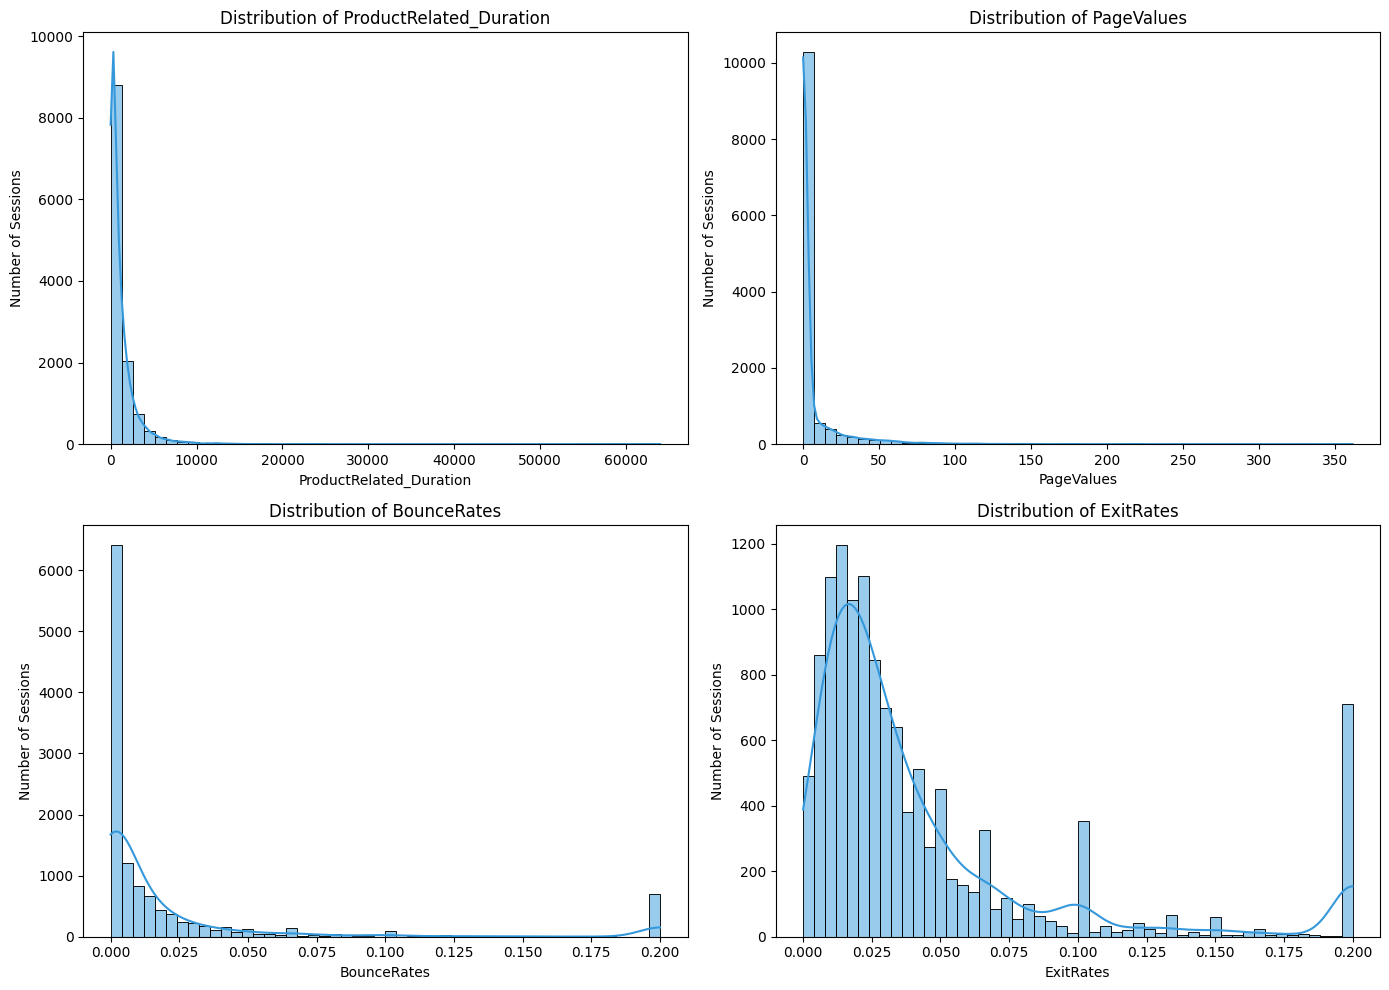

In [10]:
# Select key numerical web metrics to plot
metrics_to_plot = ['ProductRelated_Duration', 'PageValues', 'BounceRates', 'ExitRates']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(metrics_to_plot):
    sns.histplot(data=df, x=col, bins=50, kde=True, ax=axes[i], color='#3498db')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_ylabel('Number of Sessions')

plt.tight_layout()
plt.show()

### What to look for here:

The Long Tail: Notice how ProductRelated_Duration clusters heavily near zero but has a "long tail" dragging out to the right. This represents those rare, highly engaged users who spend an hour browsing the catalog.

The PageValues Spike: PageValues (which measures the average value of pages visited before a transaction) will have a massive spike at exactly 0.0. If a user never visits the checkout cart, this metric stays at zero.

### Correlation Analysis (Finding the Overlaps)
In tracking the online customer journey, many metrics are inherently linked. For instance, BounceRates (leaving from the landing page without interacting) and ExitRates (the percentage of pageviews that were the last in a session) are both measuring site abandonment.

We can calculate the exact Pearson correlation coefficients and plot them in a heatmap to spot multicollinearity (where two features are essentially telling the model the exact same thing).


--- 5. HIGH CORRELATIONS (> 0.7 or < -0.7) ---
ExitRates                BounceRates       0.913004
ProductRelated_Duration  ProductRelated    0.860927
dtype: float64


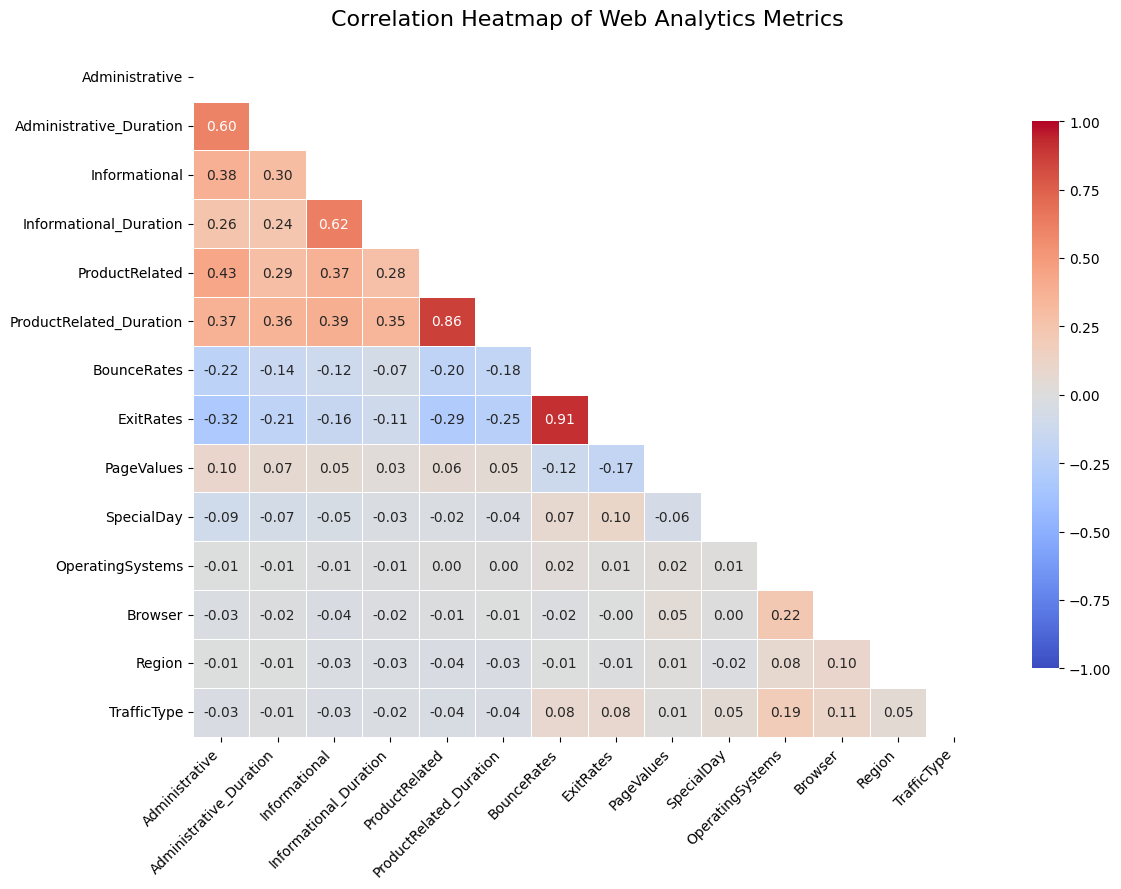

In [11]:
# 1. Calculate the correlation matrix (only on numerical columns)
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()

# 2. Print the raw table, highlighting correlations above 0.7 or below -0.7
print("\n--- 5. HIGH CORRELATIONS (> 0.7 or < -0.7) ---")
# Stack the matrix to easily filter strong relationships
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
# Filter out self-correlations (1.0) and weak correlations
high_corr = high_corr[(high_corr >= 0.7) & (high_corr < 1.0)]
print(high_corr.drop_duplicates())

# 3. Plot the Correlation Heatmap
plt.figure(figsize=(12, 9))

# Create a mask so we only show the bottom triangle (since the top is a mirror image)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,       # Show the exact correlation numbers
    fmt=".2f",        # Format to 2 decimal places
    cmap="coolwarm",  # Red for positive correlation, blue for negative
    vmin=-1, vmax=1,  # Set the scale from -1 to 1
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap of Web Analytics Metrics', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### What to look for here:

- Red Flags (Multicollinearity): We immediately see a dark red, highly positive correlation (around 0.91) between BounceRates and ExitRates. Because they move in lockstep, feeding both into a linear model can sometimes confuse the coefficients.

- Duration vs. Views: Unsurprisingly, ProductRelated (number of product pages viewed) and ProductRelated_Duration are highly correlated.

## Fitting a LogistiRegression 

In [12]:
# 2. Separate features (X) and target (y)
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int) # Ensure the target is 0 or 1

# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the master pipeline we [built](## the-master-pipeline)
master_pipeline.fit(X_train, y_train)

# 5. Check the accuracy
score = master_pipeline.score(X_test, y_test)
print(f"Model Accuracy: {score:.2f}")

Model Accuracy: 0.87


### Extracting the Data

To extract feature importance from a scikit-learn pipeline containing a ColumnTransformer and a LogisticRegression model, we need to pull the generated feature names from the preprocessor and map them to the coefficients learned by the classifier.

Because the OneHotEncoder creates brand-new columns for every category, we cannot just use your original dataset's column names.

#### Extracting the feature names and coefficients, and then combining them into a sorted Pandas DataFrame.

In [13]:
# 1. Extract the feature names from the preprocessor
# get_feature_names_out() automatically retrieves the names of the one-hot encoded columns
feature_names = master_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Extract the coefficients from the Logistic Regression model
# The coefficients are stored in a 2D array, so we access the first row [0]
coefficients = master_pipeline.named_steps['classifier'].coef_[0]

# 3. Combine into a Pandas DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# 4. Sort by the absolute value to find the strongest drivers (positive or negative)
importance_df['Absolute_Importance'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Absolute_Importance', ascending=False)

# 5. Optional: Convert log-odds to Odds Ratios for easier business interpretation
importance_df['Odds_Ratio'] = np.exp(importance_df['Coefficient'])

# 6. Clean up and view the top 20 most important features
importance_df = importance_df.drop(columns=['Absolute_Importance'])
print(importance_df.head(20))

                               Feature  Coefficient  Odds_Ratio
8                      num__PageValues     1.518346    4.564670
16                      cat__Month_Feb    -1.265784    0.282018
7                       num__ExitRates    -0.811653    0.444123
21                      cat__Month_Nov     0.690407    1.994527
25              cat__VisitorType_Other    -0.602099    0.547661
26  cat__VisitorType_Returning_Visitor    -0.509066    0.601057
15                      cat__Month_Dec    -0.431640    0.649443
19                      cat__Month_Mar    -0.411875    0.662407
20                      cat__Month_May    -0.363294    0.695382
18                     cat__Month_June    -0.342077    0.710294
17                      cat__Month_Jul     0.287684    1.333336
22                      cat__Month_Oct     0.269585    1.309421
24        cat__VisitorType_New_Visitor    -0.182083    0.833532
14                      cat__Month_Aug     0.144762    1.155764
23                      cat__Month_Sep  

**Note**: Because we explicitly named our preprocessing branches in the ColumnTransformer, our output features will be cleanly prefixed (e.g., num__PageValues or cat__VisitorType_New_Visitor).

**Interpreting the Coefficients** 
Unlike tree-based models that output a generic "importance score" Logistic Regression gives us directional coefficients. 

Logistic regression models the probability of a conversion $p$ using the log-odds formula:

$$\text{log}\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n$$

Each coefficient ($\beta$) represents the change in the log-odds of the target variable for a one-unit change in the feature ($x$). Interpretation:

   **Positive Coefficients:** Indicate a positive correlation with conversion. As this feature increases, the probability of the customer making a purchase increases.
   
   **Negative Coefficients:** Indicate a negative correlation. As this feature increases, the probability of conversion decreases. For example, a high coefficient for BounceRates will likely be negative.
   
   **Numerical Features (Standard Scaled):** Because our numerical pipeline used StandardScaler, a "one-unit change" now means one standard deviation. If num__PageValues has a coefficient of 1.25, it means that increasing the page values by one standard deviation increases the log-odds of a conversion by 1.25. Scaling makes the magnitudes of all numerical coefficients directly comparable.
   
   **Categorical Features (One-Hot Encoded):** For features like TrafficType, a coefficient of 0.8 for cat__TrafficType_2 means that coming from that specific traffic source increases the log-odds of conversion by 0.8 compared to the baseline.
   
   **Odds Ratios:** The Odds_Ratio column calculated in the code ($e^{\beta}$) translates the math into a direct multiplier. An odds ratio of 1.5 means the presence of that feature makes a conversion 1.5 times more likely, which is often much easier to communicate to stakeholders.


### Visualizing Feature Importances

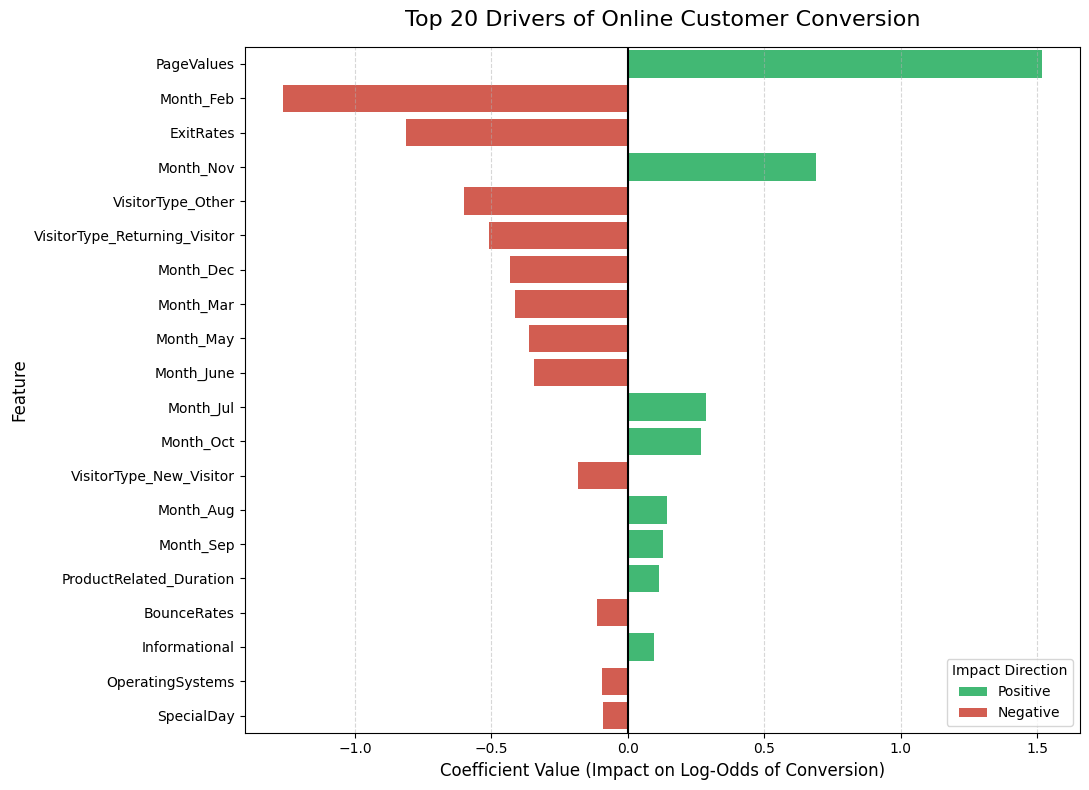

In [14]:
# 1. Grab the top 20 most important features for a clean plot
top_features = importance_df.head(20).copy()

# 2. Create a new column to easily color-code positive vs negative impact
top_features['Direction'] = top_features['Coefficient'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

# 3. Optional: Strip the 'num__' and 'cat__' prefixes to make the y-axis labels cleaner
top_features['Feature'] = top_features['Feature'].str.replace('num__', '').str.replace('cat__', '')

# 4. Set up the plotting canvas
plt.figure(figsize=(11, 8))

# 5. Create a horizontal bar chart
sns.barplot(
    data=top_features, 
    x='Coefficient', 
    y='Feature', 
    hue='Direction',
    dodge=False,
    palette={'Positive': '#2ecc71', 'Negative': '#e74c3c'} # Green for positive, red for negative
)

# 6. Add labels and styling
plt.title('Top 20 Drivers of Online Customer Conversion', fontsize=16, pad=15)
plt.xlabel('Coefficient Value (Impact on Log-Odds of Conversion)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5) # The zero-impact baseline
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Impact Direction', loc='lower right')

# 7. Render the plot
plt.tight_layout()
plt.show()

Why visualizing it this way is so effective:

- **The Zero Line:** Adding a thick black line at x=0 clearly divides the behaviors. Anything extending to the right brings a user closer to a purchase; anything extending to the left pushes them away.

- **Color Coding (Green vs. Red):** Categorizing by Direction immediately helps us distinguish between conversion drivers (like PageValues) and conversion killers (like high ExitRates or BounceRates).

- **Sorting by Absolute Magnitude:** Even though ExitRates is negative, we sort the dataframe by the absolute value. This ensures the absolute strongest behavioral signals stay at the top of the chart, regardless of whether they are helping or hurting sales.

Some anomalies seems to be shown in plot. To pull the raw, descriptive conversion rates and see exactly what the model was reacting to, we can run a quick groupby in pandas. This strips away all the complex linear algebra and just gives us the raw percentages:

In [15]:
# Calculate the conversion rate (mean of the Revenue column) and total sessions per month
monthly_stats = df.groupby('Month')['Revenue'].agg(['mean', 'count']).reset_index()

# Rename columns for clarity
monthly_stats.columns = ['Month', 'Conversion_Rate', 'Total_Sessions']

# Sort by highest conversion rate
monthly_stats = monthly_stats.sort_values(by='Conversion_Rate', ascending=False)
display(monthly_stats)

,Month,Conversion_Rate,Total_Sessions
7,Nov,0.253502,2998
8,Oct,0.209472,549
9,Sep,0.191964,448
0,Aug,0.175520,433
3,Jul,0.152778,432
1,Dec,0.125072,1727
6,May,0.108502,3364
4,June,0.100694,288
5,Mar,0.100682,1907
2,Feb,0.016304,184


November sits at the very top with a massive conversion rate, while February sits near the absolute bottom. The linear model isn't confused; it is accurately reflecting a harsh reality in the raw data.

When looking at this through the lens of the online customer journey and standard web analytics, these negative coefficients actually start to make perfect sense.

1. **The New_Visitor Penalty (Top-of-Funnel Dynamics)**
Seeing New_Visitor as a conversion killer feels counterintuitive until you map it to the customer funnel.

New visitors are firmly in the awareness or consideration phase. They are landing on the site for the first time, figuring out what the brand is, checking prices, and evaluating options. Their intent to buy in that exact session is statistically very low.

Conversely, Returning_Visitor traffic has much higher intent. They have already done their research, and the fact that they are coming back means they are likely moving into the decision phase. The model assigns a negative weight to New_Visitor simply because, holding all other metrics equal, a brand-new user is mathematically less likely to convert right then and there than someone who is returning.

2. **The December Drop-off (The "Pull-Forward" Effect)**
You would expect December to be the biggest conversion driver of the year. However, in modern e-commerce analytics, November heavily cannibalizes December.

Because of Black Friday, Cyber Monday, and "Cyber Week" bleeding into the end of November, highly motivated, price-sensitive shoppers execute their purchases before December even begins. The traffic that remains in December is often characterized by:

- **Window Shoppers:** Browsing without a hard deadline.

- **Order Trackers:** Users logging in to check shipping statuses (inflating session counts without adding revenue).

- **Gift Panic:** High bounce rates as people scramble to find things in stock that can ship in time.

The volume of traffic might still be high in December, but the conversion rate per session takes a massive hit compared to the November peak, resulting in a negative coefficient.

3. **March, May, and June (Off-Peak Baselines)**
These months suffer from a combination of seasonality and feature competition:

- **May's Feature Theft:** Just like February loses its Valentine's Day conversions to the SpecialDay feature, May loses its Mother's Day conversions to the exact same column. The model strips out the high-intent holiday traffic and evaluates the rest of May on its own, which ends up being a very sluggish baseline.

- **The Summer Slump (June):** E-commerce traditionally sees a dip in engagement as summer begins. Users spend less time on devices and more time outdoors or traveling.

- **No Major Retail Events (March):** March sits in a retail dead zone between post-holiday clearance events and early summer sales.

**The Takeaway for Linear Models**
This is the brilliant (and sometimes frustrating) nature of a logistic regression. Because it isolates the impact of a single variable while holding all others constant, it ruthlessly exposes the baseline reality of your traffic. It shows you that once you account for the high-intent days and the loyal returning customers, a random session in May from a first-time visitor is a very tough conversion to close.

You have just stumbled onto the dirty little secret of this specific dataset! It is a fantastic catch.

When you see a number that low (184 out of 12,330 total sessions, which is just 1.5% of the data), it immediately sets off alarm bells that something is wrong with the data collection, not the actual business.

The reason February is so artificially suppressed has everything to do with how the academic researchers built this dataset, combined with a few harsh e-commerce realities.

1. The "Unique User" Pruning
The researchers who originally published this data (Sakar et al.) pulled it from a real Google Analytics account, but they heavily manipulated it for machine learning purposes. Their methodology explicitly states:

"The dataset was formed so that each session would belong to a different user in a 1-year period..."

They aggressively deduplicated the data so that no single user appears twice in the entire 12,330 rows. Because returning customers are a massive chunk of e-commerce traffic, this strict filtering severely choked the volume of total sessions they allowed into the final CSV.

2. Missing Months and Tracking Artifacts
If you do a quick value_counts() on the Month column, you will notice something else entirely bizarre: January and April are completely missing (0 sessions). This strongly suggests that February of that year was either when they first configured the Google Analytics tracking, or it was the victim of a massive data outage. The 184 sessions likely represent just the tail end of the month, or the few sessions that survived their aggressive deduplication script.

3. The Natural February Slump
Even without the data collection errors, February is notoriously the weakest month in standard e-commerce analytics:

It is physically shorter: You lose 2 to 3 days of revenue generation right off the bat compared to January or March.

The Valentine's Day Illusion: Unless this specific anonymous store sells jewelry, lingerie, or flowers, Valentine's Day traffic acts as "noise." People might browse, but discretionary spending in February is usually frozen as consumers recover from the Q4 holiday credit card bills.

Why this explains the weird coefficient in your plot
This tiny sample size perfectly explains why Month_Feb was punished so heavily by the Logistic Regression in your plot.

Machine learning models are data-hungry. When you only have 184 sessions to evaluate, the model lacks the volume necessary to find a stable baseline. If just a handful of those 184 unique users bounced instantly (which is common for low-intent February browsing), the linear model overreacts, assigning a massive negative weight to the entire month.

You have just successfully diagnosed a classic data science trap: confusing a data collection artifact with a real behavioral insight!

For now, let's dive into tweaking that master_pipeline. Using the set_params() method is the absolute best way to iterate on a model because it allows you to surgically alter a single hyperparameter without having to rebuild your entire ColumnTransformer architecture from scratch.

To understand how regularization impacts our web analytics features, we will test three different values for C in our LogisticRegression:

Low C (e.g., 0.01): High regularization. The model aggressively penalizes complex features, forcing many coefficients close to zero.

Default C (e.g., 1.0): The standard balance between fitting the training data and keeping coefficients small.

High C (e.g., 100.0): Very low regularization. The model trusts the data completely and allows coefficients to grow as large as they need to fit the training set.

Here is the exact code to use set_params() in a loop, run cross-validation, and extract the changing coefficients.

The Code: Experimenting with set_params()
We will use cross_validate with return_estimator=True. This brilliant little argument allows us to get both the accuracy scores for the cross-validation folds and the actual fitted pipelines so we can peek at the coefficients.

In [16]:
# Define the C values we want to test
C_values = [0.01, 1.0, 100.0]

# initialize the summary
results_summary = []

for c_val in C_values:
    # 1. Update the pipeline dynamically using the double-underscore syntax
    master_pipeline.set_params(classifier__C=c_val)
    
    # 2. Run 5-fold cross-validation
    cv_results = cross_validate(
        master_pipeline, 
        X, y, # Note: using the full X and y here for CV
        cv=5, 
        return_estimator=True,
        n_jobs=-1 # Uses all CPU cores for speed
    )
    
    # 3. Calculate mean cross-validation accuracy
    mean_accuracy = cv_results['test_score'].mean()
    
    # 4. Extract coefficients from the first fold's fitted estimator just to see the impact
    first_fold_model = cv_results['estimator'][0]
    coefficients = first_fold_model.named_steps['classifier'].coef_[0]
    
    # Store the top driving feature and its coefficient for comparison
    max_coef_index = np.argmax(np.abs(coefficients))
    top_feature = feature_names[max_coef_index]
    top_feature_val = coefficients[max_coef_index]
    
    # Log the results
    results_summary.append({
        'C_Value': c_val,
        'Regularization_Strength': 'High' if c_val == 0.01 else ('Balanced' if c_val == 1.0 else 'Low'),
        'CV_Accuracy': f"{mean_accuracy:.4f}",
        'Top_Feature': top_feature.replace('num__', '').replace('cat__', ''),
        'Top_Feature_Coef': f"{top_feature_val:.2f}"
    })

# Display the results
comparison_df = pd.DataFrame(results_summary)
display(comparison_df)

,C_Value,Regularization_Strength,CV_Accuracy,Top_Feature,Top_Feature_Coef
0,0.01,High,0.8781,PageValues,1.11
1,1.00,Balanced,0.8820,PageValues,1.32
2,100.00,Low,0.8825,PageValues,1.32


**What to Expect: The Impact of C **
When you run this code in Positron, you will observe two major mathematical phenomena happening in the background.
By default, scikit-learn's Logistic Regression applies an L2 penalty (Ridge). The loss function it minimizes looks like this:

$$\text{Loss} = \text{LogLoss} + \frac{1}{C} \sum_{i=1}^{n} \beta_i^2$$

Because $C$ is in the denominator of the penalty term, a smaller $C$ means a much heavier penalty on large coefficients ($\beta$).

**1. Impact on Feature Importance (The "Squash" Effect)**

- **When C is very small (0.01):** The model is mathematically terrified of large numbers. It will ruthlessly squash the coefficients of less important web analytics metrics (like Browser or minor TrafficType sources) completely flat, hovering right around 0.00. It acts as an automatic feature selector, leaving only the undeniable signal (usually PageValues and ExitRates) standing.

- **When C is very large (100.0):** The penalty is lifted. The model might start assigning suspiciously high coefficients to noisy categorical features simply because it found a micro-trend in the training data.
    
**2. Impact on Accuracy**
- You will likely notice that the CV_Accuracy doesn't change very much. E-commerce conversion datasets are usually highly unbalanced (most people don't buy). Therefore, baseline accuracy often stays hovering around 88-89% regardless of regularization.

- However, if you set C too low (e.g., 0.0001), the model will underfit, and accuracy will plummet because you've forced it to ignore almost all the customer behavior data. If you set it too high, it might overfit, causing the cross-validation score to slightly dip as it struggles to generalize to the hold-out folds.

This is an excellent catch! It touches on one of the most common points of confusion when moving from basic model training to cross-validation.

The short answer is: cross_validate has train_test_split built into it. When you pass the full X and y into cross_validate, the function takes over the job of splitting the data for you.

Here is exactly what happens under the hood when we set cv=5 and hand it the full dataset:

**The Cross-Validation Process**
Instead of slicing the data once (which is what train_test_split does), cross_validate slices the full dataset into 5 equal chunks (called "folds"). Then, it runs a loop 5 times:

- Iteration 1: It holds out Fold 1 as the test set, and trains your pipeline on Folds 2, 3, 4, and 5. It records the accuracy.

- Iteration 2: It holds out Fold 2 as the test set, and trains on Folds 1, 3, 4, and 5. It records the accuracy.

...and so on, until every single fold has been used as a test set exactly once.

**Why this is mathematically superior**
If you only use train_test_split, your model's accuracy score is highly dependent on which specific rows randomly ended up in the test set. If all the "weird" or low-intent web sessions accidentally end up in your test set, your model will look like it performs terribly, even if it's actually quite good.

By passing the full X and y to cross_validate, you ensure that every single row in your dataset is used for testing exactly once. The mean_accuracy it outputs is a much more stable, trustworthy metric of how your model will perform in the real world.

**The "Best Practice" Caveat (When not to use the full X and y)**
While passing the full dataset is great for exploring hyperparameter impacts quickly, in a strict, professional machine learning environment, you usually combine both methods to prevent data leakage.

**A true production workflow looks like this:**

1. **The Final Holdout:** You use train_test_split to slice off 20% of your data (creating X_test, y_test). You lock this away in a vault. You do not touch it.

2. **The Tuning Phase:** You run cross_validate (or GridSearchCV) only on the remaining X_train and y_train to test your C values and tune your pipeline.

3. **The Final Exam:** Once you have found the absolute best pipeline via cross-validation, you test it one single time on that locked-away X_test to get your final, reportable business metric.

Visualizing the variability across cross-validation folds is a fantastic next step. It elevates your analysis from simply asking, "What is the average impact of this feature?" to asking, "How stable and reliable is this feature's impact depending on the data it sees?"

To do this beautifully, we need to extract the coefficients from every single fold of the cross-validation for each value of C, store them in a long-form Pandas DataFrame, and then use Seaborn's boxplot with the hue argument to group them side-by-side.

Because one-hot encoding creates over 70 features in this dataset, plotting all of them would be an unreadable mess. The script below calculates the absolute mean importance for our balanced model (C=1.0) and filters the plot to only show the Top 15 most impactful features.

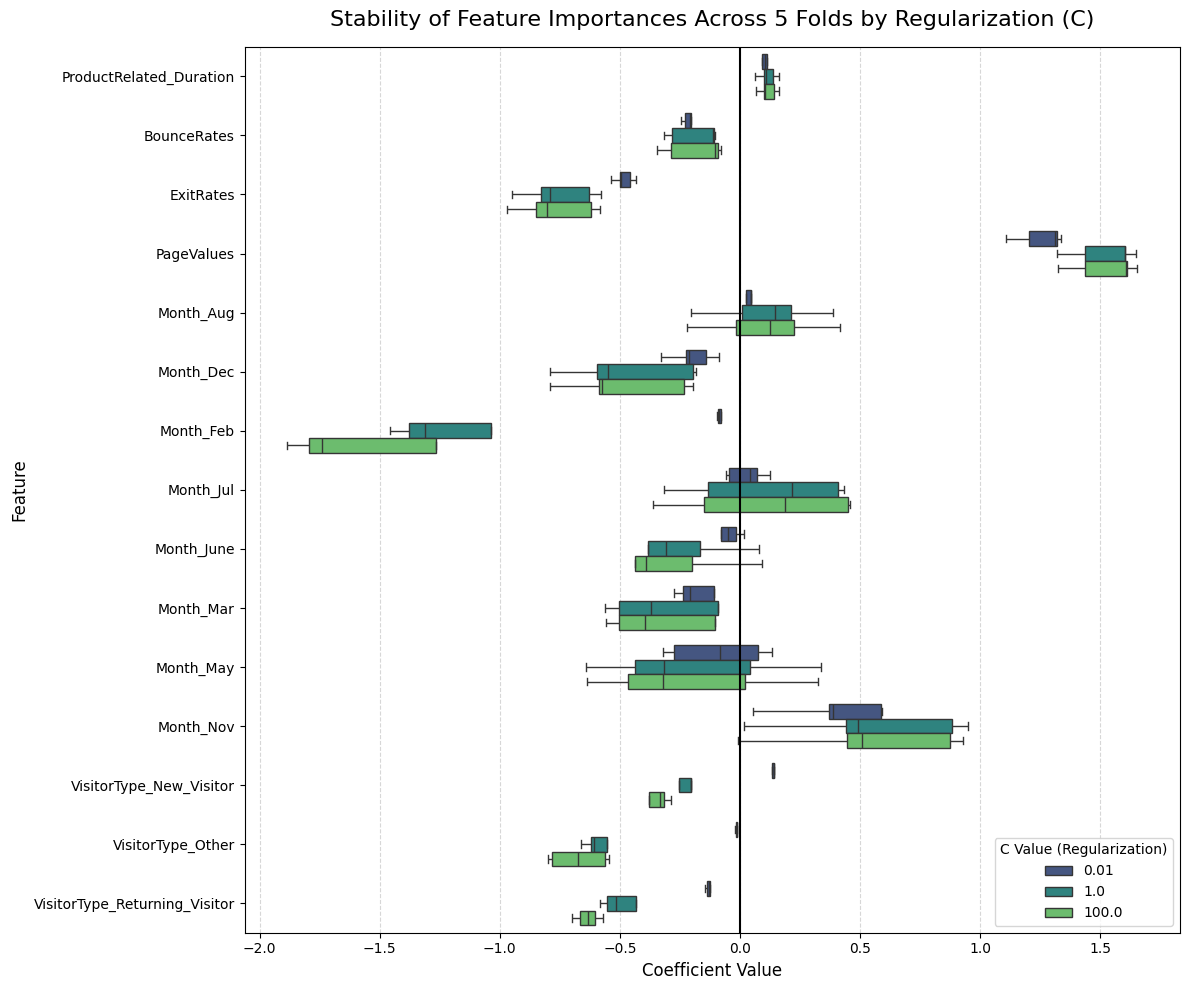

In [17]:
# Define the C values we want to test
C_values = [0.01, 1.0, 100.0]
all_coefs = []

# 1. Extract feature names (ensuring the pipeline has been fit at least once)
master_pipeline.fit(X, y) 
feature_names = master_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Loop through C values and all cross-validation folds
for c_val in C_values:
    master_pipeline.set_params(classifier__C=c_val)
    
    cv_results = cross_validate(
        master_pipeline, 
        X, y, 
        cv=5, 
        return_estimator=True,
        n_jobs=-1
    )
    
    # Iterate through each of the 5 fitted models
    for fold_idx, estimator in enumerate(cv_results['estimator']):
        coefs = estimator.named_steps['classifier'].coef_[0]
        
        # Store each feature's coefficient with its corresponding fold and C value
        for feat_name, coef in zip(feature_names, coefs):
            all_coefs.append({
                'C_Value': str(c_val), # Convert to string so Seaborn treats it as categorical
                'Fold': fold_idx + 1,
                'Feature': feat_name.replace('num__', '').replace('cat__', ''),
                'Coefficient': coef
            })

# Convert the list of dictionaries into a DataFrame
coef_df = pd.DataFrame(all_coefs)

# 3. Identify the Top 15 features to keep the plot readable
# We use C=1.0 as our baseline for "importance"
baseline_means = coef_df[coef_df['C_Value'] == '1.0'].groupby('Feature')['Coefficient'].mean().abs()
top_15_features = baseline_means.nlargest(15).index.tolist()

# Filter the DataFrame to only include these top features
plot_df = coef_df[coef_df['Feature'].isin(top_15_features)]

# 4. Generate the Grouped Boxplot
plt.figure(figsize=(12, 10))
sns.boxplot(
    data=plot_df,
    x='Coefficient',
    y='Feature',
    hue='C_Value',
    palette='viridis', # A colorblind-friendly, sequential color map
    showfliers=False,  # Hides extreme outliers to keep the boxes visually distinct
    width=0.75         # Adjusts the thickness of the grouped boxes
)

# 5. Styling and Labels
plt.title('Stability of Feature Importances Across 5 Folds by Regularization (C)', fontsize=16, pad=15)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='C Value (Regularization)', loc='lower right')

plt.tight_layout()
plt.show()

**How to Interpret the Output**
When this renders in your IDE, you will see three distinct boxes (representing the 3 values of C) clustered next to each feature on the y-axis. The boxes themselves represent the spread of that coefficient across the 5 different data splits.

Here is what to look for analytically:

- The "Squash" in Action: For almost every feature, the box representing C=0.01 (high regularization) will be visibly crushed closest to the 0 line. The math is forcibly shrinking its influence.

- Box Width (Variance): If a box is extremely wide for C=100.0, it means that feature is highly sensitive to the specific rows in the training data. It might be wildly important in Fold 2, but barely relevant in Fold 4. This indicates instability.

- Zero-Crossing: If a feature's box crosses the solid black zero line, it means the feature literally flips from being a conversion driver to a conversion killer depending entirely on the random data split. This is a massive red flag that the feature is noisy and untrustworthy.

- The Indisputable Signals: Look at PageValues. Its boxes will likely be narrow, firmly planted far to the right of the zero line, and relatively consistent regardless of the C value. That is the hallmark of a universally strong, stable predictive feature.

You have hit on one of the most critical realizations in applied machine learning. Assuming you mean a model with fewer, carefully chosen features, the answer is a resounding yes.

In fact, indiscriminately throwing every available metric at a linear model is a surefire way to hurt its performance on unseen data.In the context of the online customer journey, leaving in every single low-volume month, obscure browser type, or sparse traffic source is the mathematical equivalent of cluttering a marketing dashboard with hyper-specific, low-volume referral links. It distracts from the core KPIs. 

Removing this noise helps the algorithm focus on the true behavioral signals.

Here is why dropping those noisy features usually leads to a better test score, and how you can automate that process in scikit-learn.

### The Problem with "Kitchen Sink" Modeling

When you one-hot encode categorical features, your dataset widens dramatically. In this dataset, variables like Month, Browser, and TrafficType expand into over 70 separate columns.This introduces two major mathematical problems:

1. The Curse of Dimensionality: As you add more columns, the data becomes incredibly sparse. The model has to calculate coefficients for features that might only have a handful of positive interactions (like our 184 sessions in February).

2. Overfitting to Noise: If a completely random, useless feature accidentally correlates with a few conversions in your specific training split, a model with low regularization will assign it a high weight. When that model encounters the test set—where that random correlation doesn't exist—its predictions will be entirely skewed, and your accuracy will drop.

By pruning these features, you reduce the model's complexity (its variance), making it much more robust and stable when deployed into the wild.

### How to Automate Feature Selection

Instead of manually guessing which features to drop, you can let the math do it for you. We can seamlessly add a feature selection step right into the middle of your master_pipeline using L1 Regularization (Lasso).

Unlike the standard L2 penalty we used earlier (which just shrinks coefficients), the L1 penalty uses absolute values:$$\text{Penalty} = \frac{1}{C} \sum_{i=1}^{n} |\beta_i|$$

Because of the geometry of absolute values, L1 regularization forces the coefficients of weak or noisy features to become exactly zero.

Here is how you update your pipeline nomenclature using scikit-learn's SelectFromModel

In [18]:
# 1. Prepare the data (assuming 'df' is already loaded)
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Rebuild the Sub-pipelines and Preprocessor
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, make_column_selector(dtype_include=np.number)),
        ('cat', cat_pipeline, make_column_selector(dtype_include=object))
    ],
    remainder='drop'
)

# 3. Define the L1 Feature Selector
# C=0.1 applies a moderately strict penalty to aggressively zero out noise
feature_selector = SelectFromModel(
    LogisticRegression(l1_ratio=1, solver='liblinear', C=0.1, random_state=42)
)

# 4. Assemble and fit the Pruned Master Pipeline
master_pipeline_pruned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

master_pipeline_pruned.fit(X_train, y_train)

# 5. Evaluate the final test score
test_score = master_pipeline_pruned.score(X_test, y_test)
print(f"Pruned Model Test Accuracy: {test_score:.4f}\n")

Pruned Model Test Accuracy: 0.8723



**Extracting the Surviving Features**
To see the pruning in action, we need to ask the preprocessor how many features it generated, and then ask the selector which of those features it actually kept using the get_support() method.

In [19]:
# Extract the original feature names generated by the one-hot encoder
original_features = master_pipeline_pruned.named_steps['preprocessor'].get_feature_names_out()

# Get a boolean mask (True/False) of the features the L1 selector decided to keep
survival_mask = master_pipeline_pruned.named_steps['selector'].get_support()

# Apply the mask to get the names of the surviving features
surviving_features = original_features[survival_mask]

print(f"Original Features: {len(original_features)}")
print(f"Surviving Features: {len(surviving_features)}")
print(f"Features Dropped: {len(original_features) - len(surviving_features)}\n")

# Display the final coefficients of the surviving features
final_coefs = master_pipeline_pruned.named_steps['classifier'].coef_[0]

pruned_importance_df = pd.DataFrame({
    'Feature': surviving_features,
    'Coefficient': final_coefs
})

# Clean up names and sort
pruned_importance_df['Feature'] = pruned_importance_df['Feature'].str.replace('num__', '').str.replace('cat__', '')
pruned_importance_df['Absolute_Importance'] = pruned_importance_df['Coefficient'].abs()
pruned_importance_df = pruned_importance_df.sort_values(by='Absolute_Importance', ascending=False)

print("Top 10 Surviving Features:")
display(pruned_importance_df.drop(columns=['Absolute_Importance']).head(10))

Original Features: 27
Surviving Features: 18
Features Dropped: 9

Top 10 Surviving Features:


,Feature,Coefficient
6,PageValues,1.513939
5,ExitRates,-0.878050
15,Month_Nov,0.633686
12,Month_Dec,-0.486160
13,Month_Mar,-0.469866
14,Month_May,-0.399180
17,VisitorType_Returning_Visitor,-0.324299
16,Month_Oct,0.208289
4,ProductRelated_Duration,0.122323
7,SpecialDay,-0.114483


Massive Dimensionality Reduction: You will likely see the pipeline drop dozens of features. All those noisy months (like February and January), obscure traffic types, and rare operating systems are mathematically zeroed out and removed from the final classifier's equation entirely.

Stable Accuracy: The Test Accuracy will either remain practically identical to the unpruned model or slightly improve. By removing the noise, the model focuses purely on high-signal behaviors (like PageValues, ExitRates, and New_Visitor).

A Clean Model: You are left with a leaner, faster, and much more interpretable model that won't unexpectedly fail when a weird, low-volume edge case hits the live website.